In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('score.csv')

In [4]:
df.describe()

,Hours,Scores
count,96.000000,96.000000
mean,5.267708,54.020833
std,2.503030,25.017459
min,1.000000,12.000000
25%,3.075000,30.750000
50%,5.250000,54.500000
75%,7.325000,74.250000
max,9.800000,99.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   96 non-null     float64
 1   Scores  96 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.6 KB


Text(0.5, 1.0, 'Hours vs Scores')

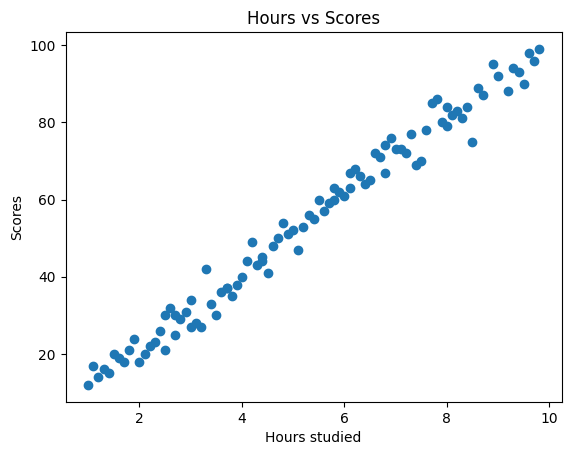

In [10]:
plt.scatter(df['Hours'],df['Scores'])
plt.xlabel('Hours studied')
plt.ylabel('Scores')
plt.title('Hours vs Scores')

In [15]:
#pause and observer// it looks like a line
X = df[['Hours']]
print(X.shape)

(96, 1)


In [18]:
from sklearn.model_selection import train_test_split
Y = df['Scores'] 
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)


In [19]:
print(X_train.shape)
print(X_test.shape)

(76, 1)
(20, 1)


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
print(model.coef_)
print(model.intercept_)

[9.95511953]
1.8407675349146686


In [ ]:
#predicting values
Y_pred = model.predict(X_test)
print(Y_pred)

[96.41440304 55.59841298 20.75549464 28.71959026 74.51314008 21.75100659
 18.76447073 52.61187712 24.73754245 62.56699665 91.43684328 23.74203049
 93.42786718 14.78242292 54.60290103 38.67470978 98.40542695 51.61636517
 94.42337914 83.47274766]


In [28]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y_test,Y_pred)
r2 = r2_score(Y_test,Y_pred)
print("MSE: ",mse)
print("R2: ",r2)

MSE:  8.339603241760788
R2:  0.9900832343491238


Measures error

Lower = better



R² Score

How well model explains data

Closer to 1 = better

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

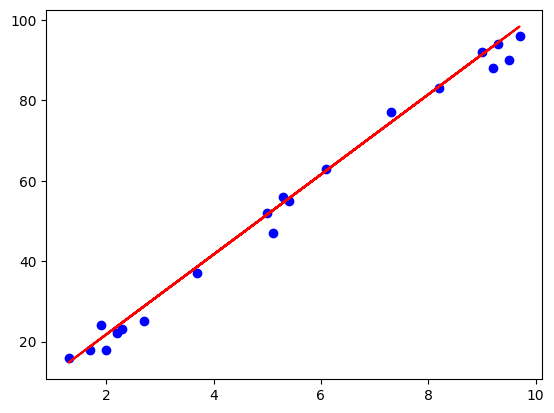

In [29]:
plt.scatter(X_test, Y_test, color='blue')
plt.plot(X_test, Y_pred, color='red')
plt.show()